<div class="alert alert-block alert-success" style="font-family:Times New Roman;color:#FFFFFF;background-color: #E7E7E7">
<h1 align="center"><span style="font-family:Times New Roman;color:#046D0B"><b>Bioestadística para Investigación Científica <br>usando Python con Inteligencia Artificial</b></span></h1>
</div>
<style>
table tr:last-child td:last-child {
  border-bottom-right-radius: 0.5rem;
}
</style>


<table align="center" style="font-size: 13px;">
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Autor</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:VR ROJAS</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Email</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:sacha.analytics@gmail.com</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Web</span></th>
    <th align="left">:<a href="https://sacha-analytics.github.io/" style="font-family:Monospace;font-size: 13px;">sacha-analytics</a></th>
</tr>
</table>
<br>

# 2. <b>Diseño de Caso Estudio:</b> Dengue</span></h1>

El dengue es una **enfermedad viral aguda** transmitida por **mosquitos**, causada por el virus del dengue (DENV), que pertenece al género Flavivirus y la familia Flaviviridae. Existen cuatro serotipos del virus (DENV-1, DENV-2, DENV-3 y DENV-4), lo que significa que una persona puede **infectarse hasta cuatro veces en su vida**, una por cada serotipo. El dengue es una **enfermedad tropical** y **subtropical** que afecta a millones de personas anualmente, especialmente en regiones urbanas y semiurbanas de América Latina, Asia, África y el Caribe.

**Fuentes**
* <a href="https://www.who.int/es/news-room/fact-sheets/detail/dengue-and-severe-dengue">Organización Mundial de la Salud (OMS)</a>

# **I. Marco Teórico**




## **1.1 Objetivo**

Analizar la distribución y características de casos de **Dengue** en función de las variables **Sexo, Edad** y **Tipo de Diagnóstico** utilizando métodos bioestadístico.

## **1.2 Fundamentos Bioestadisiticos**

### **1.2.1 Tipos de variables**
* **Sexo**: categórica nomial (Femenino, Masculino).
* **Edad**: cuantitativa continua.
* **Tipo de Diagnóstico (Tipo de Dx)**: categórica nominal


### **1.2.2 Métodos estadísticos relevantes**
* Estadística descriptiva univariada y bivariada
* Distribución de frecuencias.
* Medidas de tendencia central y dispersión.
* Prueba de independencia (Chi-cuadrado)
* Comparaciones de medidas (t-test, ANOVA)
* Modelos de regresión logística (para predecir DX)
* Modelos multivariantes (regresión logística si se desea modelar probabilidad de anemia)
* Validación de supuestos estadísticos

# **II. Recolección de Datos**

## **2.1. Fuentes de datos**

* <a href="https://www.datosabiertos.gob.pe">Plataforma Nacional de Datos Abiertos</a>.

* Datos para caso estudio estudio: <a href="https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiol%C3%B3gica-de-dengue">dengue</a>.

# **III. Metodología Práctica**

## **3.1. Montar Drive a Google Colaboratory**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'imp'

En la siguiente celda de código se define la ruta de  **Drive** en la computadora en la nube

In [2]:
drive_dir = "/content/drive/MyDrive/"

print(drive_dir)

/content/drive/MyDrive/


La funión `explorar_drive` permite inspeccionar cada carpeta y subcarpetas que se encuentran en el **Drive**

In [3]:
def explorar_drive(nombre_carpeta):
  import os
  ruta_drive ="/content/drive/MyDrive/"
  contenido_carpeta = os.listdir(ruta_drive + nombre_carpeta)
  n_elem = len(contenido_carpeta)

  print(f"Ruta: {ruta_drive + nombre_carpeta}")
  print(f"Numero de elementos: {n_elem}")

  for i in range(n_elem):
    print(f"({i}) {contenido_carpeta[i]}")

In [4]:
explorar_drive("Base_datos")

Ruta: /content/drive/MyDrive/Base_datos
Numero de elementos: 5
(0) fuente_de_datos.gdoc
(1) shapes
(2) biomedicina
(3) meteorologia
(4) finanzas


In [5]:
explorar_drive("Base_datos/biomedicina")

Ruta: /content/drive/MyDrive/Base_datos/biomedicina
Numero de elementos: 13
(0) datos_abiertos_vigilancia_dengue_2000_2023.csv
(1) datos_abiertos_vigilancia_malaria_2000_2008.csv
(2) datos_abiertos_vigilancia_malaria_2009_2023.csv
(3) Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Diabetes_202001_202404.csv
(4) datos_abiertos_vigilancia_zoonosis_2000_2023.csv
(5) datos_abiertos_vigilancia_iras_2000_2023.csv
(6) datos_abiertos_vigilancia_enfermedad_carrion_2000_2023.csv
(7) pmGenoma_25Septiembre2021.csv
(8) pmGenoma_27Sep2023.csv
(9) primeras_100_filas_anemia.gsheet
(10) TB_DIGTEL_ANEMIA_TRATAMIENTOS.csv
(11) analisis_datos.docx
(12) primeras_100_filas_anemia.xlsx


## **3.2 Preparar Entorno**

In [6]:
# Paquete especializado en metodos numericos
import numpy as np

# Paquete especialozado manejo de estructuras de datos tipo tablas (Data Frames)
import pandas as pd

# Paquetes especializado para generar graficas
import seaborn as sns
import matplotlib.pyplot as plt

# Paquete especializados de estadística y metodos numéricos
from scipy import stats

# Paquete especializado en estadística
import statsmodels.api as sm
import statsmodels.formula.api as smf
#from statsmodels.formula.api import ols

## **3.3. Importar Base de Datos de Dengue**

In [7]:
nombre_archivo = "datos_abiertos_vigilancia_dengue_2000_2023.csv"
data_dir = "/content/drive/MyDrive/Base_datos/biomedicina/"

df_dengue = pd.read_csv(data_dir + nombre_archivo)
print(df_dengue)

       departamento      provincia                distrito  \
0           HUANUCO  LEONCIO PRADO                 LUYANDO   
1           HUANUCO  LEONCIO PRADO                 LUYANDO   
2           HUANUCO  LEONCIO PRADO  JOSE CRESPO Y CASTILLO   
3           HUANUCO  LEONCIO PRADO  JOSE CRESPO Y CASTILLO   
4           HUANUCO  LEONCIO PRADO   MARIANO DAMASO BERAUN   
...             ...            ...                     ...   
757885       TUMBES         TUMBES                  TUMBES   
757886       TUMBES         TUMBES                  TUMBES   
757887       TUMBES         TUMBES                  TUMBES   
757888       TUMBES         TUMBES                  TUMBES   
757889       TUMBES         TUMBES                  TUMBES   

                         enfermedad   ano  semana diagnostic tipo_dx  diresa  \
0       DENGUE SIN SIGNOS DE ALARMA  2000      47      A97.0       P    10.0   
1       DENGUE SIN SIGNOS DE ALARMA  2000      40      A97.0       P    10.0   
2       DENGUE 

## **3.4. Revisión Metadatos**

In [8]:
lista_variables = df_dengue.columns.to_list()
print(lista_variables)

['departamento', 'provincia', 'distrito', 'enfermedad', 'ano', 'semana', 'diagnostic', 'tipo_dx', 'diresa', 'ubigeo', 'edad', 'tipo_edad', 'sexo']


In [9]:
for i in range(len(lista_variables)):
  print(f"{i}. {lista_variables[i]}")

0. departamento
1. provincia
2. distrito
3. enfermedad
4. ano
5. semana
6. diagnostic
7. tipo_dx
8. diresa
9. ubigeo
10. edad
11. tipo_edad
12. sexo


In [10]:
print(df_dengue["tipo_dx"].value_counts())

tipo_dx
C    652086
P    105804
Name: count, dtype: int64


### **3.4.1. tipo_Dx:** Confirmado (C)
Un caso se considera confirmado cuando cumple criterios de laboratorio para dengue, independientemente de la sintomatología clínica.

### **3.4.2. tipo_Dx:** Probable (P)
Un caso se clasifica como probable cuando hay compatibilidad clínica y apoyo epidemiológico o serológico, pero sin confirmación por pruebas específicas.

###**3.4.3. tipo_Dx:** Sospechoso (S)
Un caso se considera sospechoso cuando presenta síntomas sugerentes, pero sin pruebas de laboratorio ni nexo epidemiológico confirmado.

**Fuentes**

* <a href="https://www.datosabiertos.gob.pe/dataset/anemia">Plataforma de datos abiertos del Perú</a>.

* <a href="https://www.who.int/publications/i/item/9789241547871">Organización Mundial de la Salud (OMS)</a>

###**3.4.4. Elección de variables de interés**

In [11]:
df_interes = df_dengue[["ano","departamento", "sexo","edad","tipo_edad","enfermedad","tipo_dx"]].dropna()
print(df_interes)

         ano departamento sexo  edad tipo_edad                   enfermedad  \
0       2000      HUANUCO    M     9         A  DENGUE SIN SIGNOS DE ALARMA   
1       2000      HUANUCO    F    18         A  DENGUE SIN SIGNOS DE ALARMA   
2       2000      HUANUCO    F    32         A  DENGUE SIN SIGNOS DE ALARMA   
3       2000      HUANUCO    F    40         A  DENGUE SIN SIGNOS DE ALARMA   
4       2000      HUANUCO    M    16         A  DENGUE SIN SIGNOS DE ALARMA   
...      ...          ...  ...   ...       ...                          ...   
757885  2023       TUMBES    F     8         A  DENGUE SIN SIGNOS DE ALARMA   
757886  2023       TUMBES    M     7         A  DENGUE SIN SIGNOS DE ALARMA   
757887  2023       TUMBES    M     6         A  DENGUE SIN SIGNOS DE ALARMA   
757888  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   
757889  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   

       tipo_dx  
0            P  
1            P  


In [12]:
print(df_interes["departamento"].value_counts())

departamento
PIURA            205714
LORETO            99078
UCAYALI           51881
LA LIBERTAD       50879
LAMBAYEQUE        47078
TUMBES            40204
ICA               38213
LIMA              34990
SAN MARTIN        33649
MADRE DE DIOS     32415
CAJAMARCA         26861
JUNIN             22779
ANCASH            18872
AMAZONAS          15288
CUSCO             13106
HUANUCO           11344
AYACUCHO           9584
PASCO              3119
CALLAO             2382
PUNO                446
AREQUIPA              7
MOQUEGUA              1
Name: count, dtype: int64


## **3.5 Análisis Estadístico Descriptivo Univariado y Bivariado**

Esta sección se enfoca en realizar análisis estadístico descriptivo sobre las variables seleccionadas del DataFrame `df_interes`: Sexo, Edad y Tipo_Dx. Cubriremos estadísticas descriptivas univariadas (análisis de variable individual) y bivariadas (análisis de la relación entre dos variables).

###**3.5.1 Distribución de frecuencia de datos categóricos por columna (análisis univariado)**

Para variables categóricas como **Sexo, Tipo_edad** y **Tipo_Dx**, el análisis descriptivo más común es observar la distribución de frecuencias. Esto nos indica cuántas veces aparece cada valor único en la columna.

In [13]:
print(df_interes["sexo"].value_counts())

print(df_interes["tipo_edad"].value_counts())

print(df_interes["tipo_dx"].value_counts())

print(df_interes["enfermedad"].value_counts())

sexo
F    406976
M    350914
Name: count, dtype: int64
tipo_edad
A    752390
M      5234
D       266
Name: count, dtype: int64
tipo_dx
C    652086
P    105804
Name: count, dtype: int64
enfermedad
DENGUE SIN SIGNOS DE ALARMA    670500
DENGUE CON SIGNOS DE ALARMA     84114
DENGUE GRAVE                     3276
Name: count, dtype: int64


In [14]:
print(df_interes["edad"].value_counts())

edad
14       18074
15       17900
16       17701
13       17395
12       17043
         ...  
106          1
35109        1
113          1
110          1
117          1
Name: count, Length: 122, dtype: int64


In [15]:
print(df_interes["edad"].describe())

count    7.578900e+05
mean     1.888111e+02
std      9.579848e+04
min      0.000000e+00
25%      1.500000e+01
50%      2.700000e+01
75%      4.200000e+01
max      7.196364e+07
Name: edad, dtype: float64


### **3.5.2 Relación de datos categóricos vc numéricos (análisis bivariado)**

Para explorar la relación entre una variable categórica (**Sexo**) y una variable numérica (**Edad**), un gráfico de cajas (boxplot) es una visualización adecuada.

In [16]:
df_interes = df_interes[(df_interes["edad"]>=0) & (df_interes["edad"]<100)]
print(df_interes)

         ano departamento sexo  edad tipo_edad                   enfermedad  \
0       2000      HUANUCO    M     9         A  DENGUE SIN SIGNOS DE ALARMA   
1       2000      HUANUCO    F    18         A  DENGUE SIN SIGNOS DE ALARMA   
2       2000      HUANUCO    F    32         A  DENGUE SIN SIGNOS DE ALARMA   
3       2000      HUANUCO    F    40         A  DENGUE SIN SIGNOS DE ALARMA   
4       2000      HUANUCO    M    16         A  DENGUE SIN SIGNOS DE ALARMA   
...      ...          ...  ...   ...       ...                          ...   
757885  2023       TUMBES    F     8         A  DENGUE SIN SIGNOS DE ALARMA   
757886  2023       TUMBES    M     7         A  DENGUE SIN SIGNOS DE ALARMA   
757887  2023       TUMBES    M     6         A  DENGUE SIN SIGNOS DE ALARMA   
757888  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   
757889  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   

       tipo_dx  
0            P  
1            P  


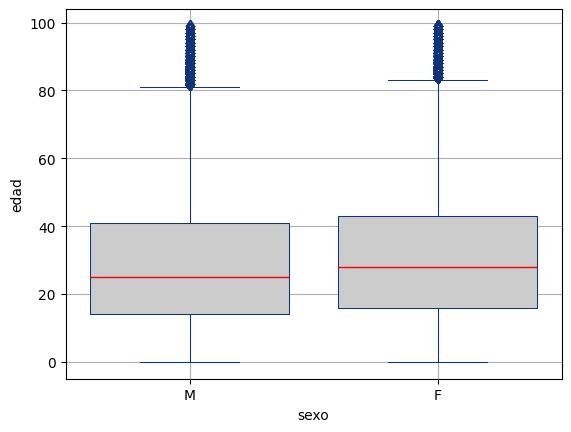

In [17]:
sns.boxplot(x="sexo", y="edad", data= df_interes,
            color=".8",
            linecolor="#137",
            linewidth=.75,
            medianprops={"color": "r", "linewidth": 1},
            flierprops={"marker": "d"},
            )
plt.grid(True)
plt.show()

### **3.5.3 Distribución de la variable "Edad"**

In [18]:
# Estadísticas descriptivas para la variable 'Edad'
print("Estadísticas Descriptivas para 'Edad':")
print(df_interes["edad"].describe())
print("\n" + "="*50 + "\n") # Separador para mayor claridad

Estadísticas Descriptivas para 'Edad':
count    757847.000000
mean         29.931325
std          18.683556
min           0.000000
25%          15.000000
50%          27.000000
75%          42.000000
max          99.000000
Name: edad, dtype: float64




Visualización de la Distribución para 'Edad' (Histograma):


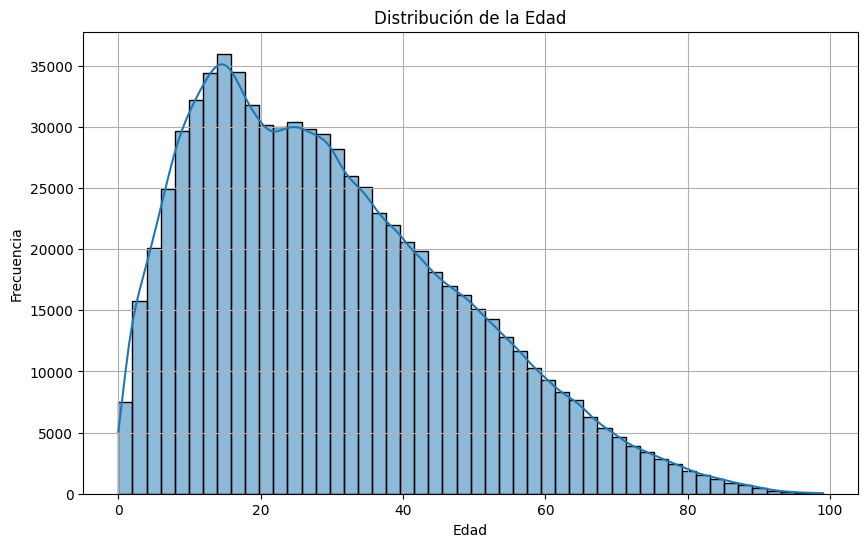

In [19]:
# Histograma para visualizar la distribución de 'Edad'
print("Visualización de la Distribución para 'Edad' (Histograma):")
plt.figure(figsize=(10, 6)) # Establece el tamaño de la figura para el gráfico
sns.histplot(df_interes["edad"], bins=50, kde=True) # Crea el histograma
plt.title("Distribución de la Edad") # Añade un título al gráfico
plt.xlabel("Edad") # Añade una etiqueta al eje x
plt.ylabel("Frecuencia") # Añade una etiqueta al eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

### **3.5.4 Análisis de Medidas de Tendencia Central y Dispersión**

Vamos a calcular medidas de tendencia central (como la media, mediana y moda) y medidas de dispersión (como la desviación estándar, varianza y rango) para las variables **Sexo, Edad** y **Tipo_Dx**.

In [20]:
# Análisis para la variable 'Edad' (Cuantitativa)
print("Análisis para la variable 'Edad':")

# Medidas de Tendencia Central para 'Edad'
print(f"  Media: {df_interes['edad'].mean():.2f}")
print(f"  Mediana: {df_interes['edad'].median():.2f}")
print(f"  Moda: {df_interes['edad'].mode()[0]}") # mode() puede devolver múltiples valores si hay un empate
print("\n")

# Medidas de Dispersión para 'Edad'
print(f"  Desviación Estándar: {df_interes['edad'].std():.2f}")
print(f"  Varianza: {df_interes['edad'].var():.2f}")
print(f"  Rango: {df_interes['edad'].max() - df_interes['edad'].min()}")
print(f"  Cuartil 1 (Q1): {df_interes['edad'].quantile(0.25):.2f}")
print(f"  Cuartil 3 (Q3): {df_interes['edad'].quantile(0.75):.2f}")
print(f"  Rango Intercuartílico (IQR): {df_interes['edad'].quantile(0.75) - df_interes['edad'].quantile(0.25):.2f}")
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Sexo' (Categórica)
print("Análisis para la variable 'Sexo':")

# Medida de Tendencia Central para 'Sexo' (Moda)
print(f"  Moda: {df_interes['sexo'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Tipo_edad' (Categórica)
print("Análisis para la variable 'Tipo_edad':")

# Medida de Tendencia Central para 'Tipo_edad' (Moda)
print(f"  Moda: {df_interes['tipo_edad'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Tipo_Dx' (Categórica)
print("Análisis para la variable 'Tipo_Dx':")

# Medida de Tendencia Central para 'Tipo_Dx' (Moda)
print(f"  Moda: {df_interes['tipo_dx'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

# Medida de Tendencia Central para 'enfermedad' (Moda)
print("Análisis para la variable 'enfermedad':")
# Medida de Tendencia Central para 'enfermedad' (Moda)
print(f"  Moda: {df_interes['enfermedad'].mode()[0]}") # La categoría más frecuente


Análisis para la variable 'Edad':
  Media: 29.93
  Mediana: 27.00
  Moda: 14


  Desviación Estándar: 18.68
  Varianza: 349.08
  Rango: 99
  Cuartil 1 (Q1): 15.00
  Cuartil 3 (Q3): 42.00
  Rango Intercuartílico (IQR): 27.00


Análisis para la variable 'Sexo':
  Moda: F


Análisis para la variable 'Tipo_edad':
  Moda: A


Análisis para la variable 'Tipo_Dx':
  Moda: C


Análisis para la variable 'enfermedad':
  Moda: DENGUE SIN SIGNOS DE ALARMA


## **3.6 Estadística inferencial:** prueba de hipótesis

### **3.6.1. Chi-cuadrado**
La prueba de hipótesis no paramétrica **Chi-cuadrado** es una técnica estadística fundamental para analizar datos categóricos, es decir, datos que se pueden agrupar en categorías (com sexo, tipo de enfermedad, opinión, etc.). Se considera **no paramétrica** porque no asume que los datos sigan una distribución de probabilidad específica (como la distribución normal), lo que la hace muy útil en situaciones donde las suposiciones de pruebas paramétricas no se cumplen.

<b>¿Por qué se usa la prueba de Chi-cuadrado?</b>
<ul>
  <li>Se aplica a <b>datos categóricos</b> en forma de tablas de frecuencias.</li>
  <li> Se utiliza para determinar si existe una relación o asociación significativa entre dos variables (<b>prueba de independencia</b>).</li>
  <li> Se usa para comparar una distribución observada con una distribución teórica (<b>prueba de bondad de ajuste</b>).</li>
  <li> Sirve para conocer si la distribución de una variable categórica es la misma en dos o más poblaciones diferentes (<b>prueba de homogeneidad</b>).</li>
</ul>

$ $

**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una relación ó asociación entre dos variables categóricas (las variables son independientes).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una relación ó asociación significativa entre dos variables categóricas.
$ $

**Interpretación**
* Si el valor p (p-value) es **mayor** que el nivel de significancia ($α = 0.05$): No se rechaza **Hipótesis Nula ($H_{0}$)**. Por tanto, no hay evidencia de relación ó asociación entre variables.

* Si el valor p es **menor** que el nivel de significancia: Se rechaza la **Hipóteisis Nula ($H_{0}$)**. Por tanto, Existe evidencia estadística de relación o asociación entre las variables.
$ $

**Consideraciones claves**

* **Tamaño muestral**: Requiere frecuencias esperadas $\geq 5$ en cada celda.
* **Variables categóricas**: No aplica para variables continuas.
* **Direccionalidad**: Chi-Cuadrado solo detecta relación o asociación , **no causalida**.

In [21]:
tabla = pd.crosstab(df_interes["sexo"], df_interes["tipo_dx"])
print(tabla)

tipo_dx       C      P
sexo                  
F        350484  56475
M        301569  49319


In [22]:
"""
Aplicar la prueba de Chi-cuadrado de independencia
---------------------------------------------------
  chi2_stat : Esta variable almacena el estadístico Chi-cuadrado

  p_valor         : Esta variable almacena el valor p, que representa la
                    la probabilidad de observar los datos si no ubiera
                    relación entre las variables

  dof             : En esta variable contine los grados de libertar, que
                    es un parámetro relacionado con el tamaño de la muestra
                    y el número de categorias en las variables.

  freq_esperadas  : A esta variable se le asigna las frecuencias esperadas
                    para cada celda de la tabla de contingencia si no hubiera
                    relación entre las variables.
"""

chi2_stat, p_valor, dof, freq_esperadas = stats.chi2_contingency(tabla)

In [23]:
print("Prueba de Chi-cuadrado de Independencia:")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Grados de libertad: {dof}")
print(f"p-valor: {p_valor:.3f}\n")

alpha = 0.05 # Nivel de significancia
# Interpretación:
print("\nResultado:")
if p_valor >= alpha:
  print("\tNo se rechaza H0:\n")
  print("\tNo hay una relación ó asociación significativa entre Sexo y Tipo_Dx.\n")
else:
  print("\tSe rechaza H0:\n")
  print("\tHay una relación ó asociación significativa entre Sexo y Tipo_Dx.\n")

Prueba de Chi-cuadrado de Independencia:
Estadístico Chi-cuadrado: 4.965
Grados de libertad: 1
p-valor: 0.026


Resultado:
	Se rechaza H0:

	Hay una relación ó asociación significativa entre Sexo y Tipo_Dx.



### **3.6.2. Comparación de medidas:** prueba de hipótesis T-test

La prueba **T-test** (también conocido como **t de Student**) se utiliza para comparar las medias de dos muestras independientes. En este caso, las dos muestras son las edades de los individuos masculinos y femeninos.

**El T-test** es una herramienta fundamental en bioestadística que permite tomar decisiones basadas en evidencia sobre diferencias entre grupos, siendo especialmente valioso en investigación médica y epidemiológica donde las decisiones pueden tener implicaciones importantes para la salud pública.



**Supuestos del T-test**
* Los datos deben seguir una distribución aproximadamente normal (verificar con histogramas o pruebas como **Shapiro-Wilk**).

**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias iguales).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias diferentes).

**Interpretación**

* si **p-valor $\lt \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: hay evidencia estadísticamente significativa de una diferencia entre los grupos. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.
* si p-valor $\geq \alpha$, **No** se **rechaza la hipótesis nula** ($H_{0}$): no hay evidencia suficiente para afirmar que las medias son distintas

In [24]:
# Separar la variable 'Edad' en dos grupos basados en la variable 'Sexo'
edad_femenino = df_interes[df_interes["sexo"] == "F"]["edad"]
edad_masculino = df_interes[df_interes["sexo"] == "M"]["edad"]

print(edad_femenino)
print(edad_masculino)

1         18
2         32
3         40
5          7
6         39
          ..
757875    35
757876    36
757877    35
757880    35
757885     8
Name: edad, Length: 406959, dtype: int64
0          9
4         16
7         31
8         13
11        32
          ..
757884    31
757886     7
757887     6
757888    11
757889    11
Name: edad, Length: 350888, dtype: int64


In [25]:
# Realizar la prueba T-test independiente
# equal_var=True asume varianzas iguales (T-test estándar).
# Si no estamos seguros de la igualdad de varianzas, podemos usar equal_var=False (Welch's T-test).
t_stat, p_valor_ttest = stats.ttest_ind(edad_femenino, edad_masculino, equal_var=True)

print("Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:")
print(f"Estadístico T: {t_stat:.3f}")
print(f"p-valor: {p_valor_ttest:.3f}\n")

# Interpretación del p-valor
alpha = 0.05 # Nivel de significancia comúnmente utilizado

print("Interpretación del resultado:")
if p_valor_ttest > alpha:
  print("\tno se rechaza H0.")
  print("\tConcluimos que no existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.")

else:
  print("\tSe rechaza H0.")
  print("\tConcluimos que existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.")


# Opcional: Mostrar las medias de edad para cada grupo
print("\nMedias de Edad por Sexo:")
print(f"\tMedia de Edad (Femenino): {edad_femenino.mean():.2f}")
print(f"\tMedia de Edad (Masculino): {edad_masculino.mean():.2f}")

Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:
Estadístico T: 39.550
p-valor: 0.000

Interpretación del resultado:
	Se rechaza H0.
	Concluimos que existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.

Medias de Edad por Sexo:
	Media de Edad (Femenino): 30.72
	Media de Edad (Masculino): 29.02


### **3.6.3. Prueba de hipótesis paramétrica Shapiro-Wilk**

La **prueba de Shapiro-Wilk** es un método estadístico utilizado para evaluar si una muestra de datos proviene de una distribución normal. Es una de las pruebas más comunes y poderosas para verificar la normalidad de los datos, lo cual es un supuesto clave en muchas pruebas estadísticas paramétricas, como la t de Student o ANOVA. En investigación, esta prueba es útil para determinar si los datos cumplen con los requisitos de normalidad antes de aplicar métodos estadísticos que asumen una distribución normal.

**Hipótesis para la prueba Shapiro-Wilk**
* **Hipótesis Nula ($H_{0}$)**: Los datos siguen una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: Los datos **No** siguen una distribución normal.

**Interpretación**

* si **p-valor $\leq \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: Los datos **no siguen una distribución normal**. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.

* si **p-valor $\gt \alpha$**, no se **rechaza la hipótesis nula** ($H_{0}$): Los datos no difieren de una distribución normal (se asume normalidad).

In [26]:
# Realizar la prueba de Shapiro-Wilk para el grupo Femenino
shapiro_femenino_stat, shapiro_femenino_p = stats.shapiro(edad_femenino)

print("Prueba de Shapiro-Wilk para la Edad (Sexo Femenino):")
print(f"Estadístico Shapiro-Wilk: {shapiro_femenino_stat:.3f}")
print(f"p-valor: {shapiro_femenino_p:.3f}\n")

# Interpretación para el grupo Femenino
alfa_shapiro = 0.05
print("Interpretación para el grupo Femenino:")
if shapiro_femenino_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_femenino_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Femenino se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_femenino_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Femenino no es significativamente normal.")


print("\n" + "="*50 + "\n") # Separador

# Realizar la prueba de Shapiro-Wilk para el grupo Masculino
shapiro_masculino_stat, shapiro_masculino_p = stats.shapiro(edad_masculino)

print("Prueba de Shapiro-Wilk para la Edad (Sexo Masculino):")
print(f"Estadístico Shapiro-Wilk: {shapiro_masculino_stat:.3f}")
print(f"p-valor: {shapiro_masculino_p:.3f}\n")

# Interpretación para el grupo Masculino
print("Interpretación para el grupo Masculino:")
if shapiro_masculino_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_masculino_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Masculino se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_masculino_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Masculino no es significativamente normal.")

print("\n" + "="*50 + "\n") # Separador

# Ahora procedemos con el T-test, considerando los resultados de la prueba de normalidad.
# Si las distribuciones no son normales, podrías considerar usar una prueba no paramétrica
# equivalente al T-test, como la prueba U de Mann-Whitney.

Prueba de Shapiro-Wilk para la Edad (Sexo Femenino):
Estadístico Shapiro-Wilk: 0.964
p-valor: 0.000

Interpretación para el grupo Femenino:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de la Edad en el grupo Femenino no es significativamente normal.


Prueba de Shapiro-Wilk para la Edad (Sexo Masculino):
Estadístico Shapiro-Wilk: 0.947
p-valor: 0.000

Interpretación para el grupo Masculino:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de la Edad en el grupo Masculino no es significativamente normal.




/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 406959.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 350888.
  res = hypotest_fun_out(*samples, **kwds)


### **3.6.4. Comparación de medidas:** Anova


  La prueba de hipótesis ANOVA (Análisis de la Varianza) es una herramienta estadística paramétrica que se utiliza para comparar las medias de tres o más grupos independientes y determinar si existen diferencias significativas entre ellas. Aunque la ANOVA es relativamente robusta a la falta de la normalidad con tamaños de muestra grandes, la homogeneidad de varianzas es más crítica.

**Nota Importante para ANOVA**

 * **Normalidad**: Las distribuciones de los residuos (o de la variable dependiente dentro de cada grupo) son aproximadamente normales.

 * **Homogeneidad de Varianzas**: Las varianzas de la variable dependiente son aproximadamente iguales en todos los grupos.

 * **Independencia**: Las observaciones son independientes.


Evaluaremos la normalidad de la variable **Edad** para cada una de las categorias de **Tipo_Dx** empleando la prueba de Shapiro-Wilk

 **Hipótesis para prueba de normalidad:** Shapiro-Wilk
* **Hipótesis Nula ($H_{0}$)**: La muestra proviene de una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: La muestra no proviene de una distribución normal.

In [27]:
# Separar la variable 'Edad' en grupos basados en la variable 'Tipo_Dx'
grupos_tipo_dx = df_interes.groupby("tipo_dx")
print(grupos_tipo_dx)

In [28]:
nombre_grupos = grupos_tipo_dx.groups.keys()
print(nombre_grupos)

dict_keys(['C', 'P'])


In [29]:
Dx_C = grupos_tipo_dx.get_group("C")
print(Dx_C["edad"].describe())

count    652053.000000
mean         30.159335
std          18.808596
min           0.000000
25%          15.000000
50%          27.000000
75%          43.000000
max          99.000000
Name: edad, dtype: float64


### **3.6.5 Modelo para tarea**

In [30]:
grupo_tipoEdad = df_interes.groupby("tipo_edad")

In [31]:
name_grupos = grupo_tipoEdad.groups.keys()
print(name_grupos)

dict_keys(['A', 'D', 'M'])


In [32]:
df_years = grupo_tipoEdad.get_group("A")
print(df_years["tipo_edad"].value_counts())

tipo_edad
A    752347
Name: count, dtype: int64


In [33]:
print(df_years["departamento"].value_counts())

departamento
PIURA            204487
LORETO            97668
UCAYALI           51114
LA LIBERTAD       50641
LAMBAYEQUE        46761
TUMBES            39946
ICA               38058
LIMA              34947
SAN MARTIN        33428
MADRE DE DIOS     32073
CAJAMARCA         26719
JUNIN             22694
ANCASH            18838
AMAZONAS          15173
CUSCO             13061
HUANUCO           11277
AYACUCHO           9528
PASCO              3100
CALLAO             2381
PUNO                445
AREQUIPA              7
MOQUEGUA              1
Name: count, dtype: int64


In [34]:
grupo_departamento = df_years.groupby("departamento")
name_departamentos = grupo_departamento.groups.keys()
print(name_departamentos)

dict_keys(['AMAZONAS', 'ANCASH', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'HUANUCO', 'ICA', 'JUNIN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LORETO', 'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTIN', 'TUMBES', 'UCAYALI'])


In [35]:
print(df_years.columns.to_list())

['ano', 'departamento', 'sexo', 'edad', 'tipo_edad', 'enfermedad', 'tipo_dx']


In [36]:
df_years_piura = grupo_departamento.get_group("PIURA")

In [37]:
print(df_years_piura["departamento"].value_counts())
print(df_years_piura["sexo"].value_counts())
print(df_years_piura["enfermedad"].value_counts())

departamento
PIURA    204487
Name: count, dtype: int64
sexo
F    112970
M     91517
Name: count, dtype: int64
enfermedad
DENGUE SIN SIGNOS DE ALARMA    181854
DENGUE CON SIGNOS DE ALARMA     21819
DENGUE GRAVE                      814
Name: count, dtype: int64


In [38]:
grupo_tipoEnfermedad = df_years_piura.groupby("enfermedad")
name_enfermedades = grupo_tipoEnfermedad.groups.keys()
print(name_enfermedades)

dict_keys(['DENGUE CON SIGNOS DE ALARMA', 'DENGUE GRAVE', 'DENGUE SIN SIGNOS DE ALARMA'])


In [39]:
df_dengue_sinAlarma = grupo_tipoEnfermedad.get_group("DENGUE SIN SIGNOS DE ALARMA")
print(df_dengue_sinAlarma["enfermedad"].value_counts())

enfermedad
DENGUE SIN SIGNOS DE ALARMA    181854
Name: count, dtype: int64


In [40]:
df_dengue_conAlarma = grupo_tipoEnfermedad.get_group("DENGUE CON SIGNOS DE ALARMA")
print(df_dengue_conAlarma["edad"].value_counts())

edad
17    519
13    515
14    508
15    507
18    498
     ... 
94      8
92      7
95      6
97      2
98      1
Name: count, Length: 98, dtype: int64


In [41]:
df_dengue_grave = grupo_tipoEnfermedad.get_group("DENGUE GRAVE")
print(df_dengue_grave["enfermedad"].value_counts())

enfermedad
DENGUE GRAVE    814
Name: count, dtype: int64


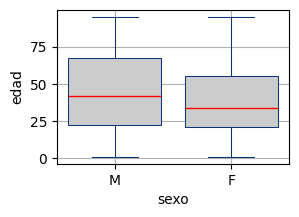

In [42]:
plt.figure(figsize=(3, 2))
sns.boxplot(x="sexo", y="edad", data= df_dengue_grave,
            color=".8",
            linecolor="#137",
            linewidth=.75,
            medianprops={"color": "r", "linewidth": 1},
            flierprops={"marker": "d"},
            )
plt.grid(True)
plt.show()

Visualización de la Distribución para 'Edad' (Histograma):


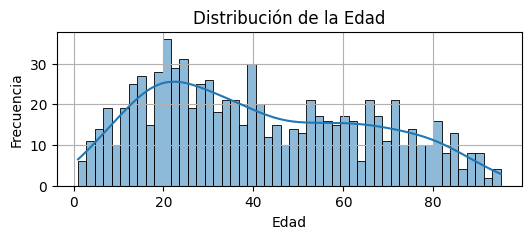

In [43]:
print("Visualización de la Distribución para 'Edad' (Histograma):")
plt.figure(figsize=(6, 2)) # Establece el tamaño de la figura para el gráfico
sns.histplot(df_dengue_grave["edad"], bins=50, kde=True) # Crea el histograma
plt.title("Distribución de la Edad") # Añade un título al gráfico
plt.xlabel("Edad") # Añade una etiqueta al eje x
plt.ylabel("Frecuencia") # Añade una etiqueta al eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

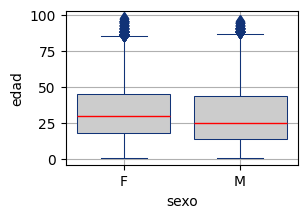

In [44]:
plt.figure(figsize=(3, 2))
sns.boxplot(x="sexo", y="edad", data= df_dengue_conAlarma,
            color=".8",
            linecolor="#137",
            linewidth=.75,
            medianprops={"color": "r", "linewidth": 1},
            flierprops={"marker": "d"},
            )
plt.grid(True)
plt.show()

Visualización de la Distribución para 'Edad' (Histograma):


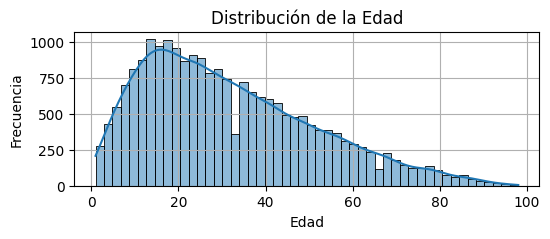

In [45]:
print("Visualización de la Distribución para 'Edad' (Histograma):")
plt.figure(figsize=(6, 2)) # Establece el tamaño de la figura para el gráfico
sns.histplot(df_dengue_conAlarma["edad"], bins=50, kde=True) # Crea el histograma
plt.title("Distribución de la Edad") # Añade un título al gráfico
plt.xlabel("Edad") # Añade una etiqueta al eje x
plt.ylabel("Frecuencia") # Añade una etiqueta al eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

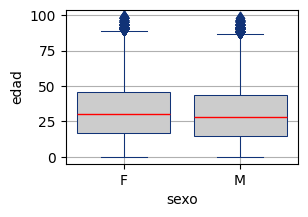

In [46]:
plt.figure(figsize=(3, 2))
sns.boxplot(x="sexo", y="edad", data= df_dengue_sinAlarma,
            color=".8",
            linecolor="#137",
            linewidth=.75,
            medianprops={"color": "r", "linewidth": 1},
            flierprops={"marker": "d"},
            )
plt.grid(True)
plt.show()

Visualización de la Distribución para 'Edad' (Histograma):


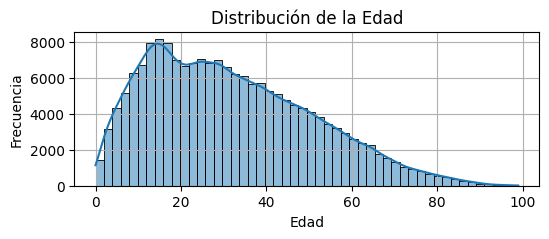

In [47]:
print("Visualización de la Distribución para 'Edad' (Histograma):")
plt.figure(figsize=(6, 2)) # Establece el tamaño de la figura para el gráfico
sns.histplot(df_dengue_sinAlarma["edad"], bins=50, kde=True) # Crea el histograma
plt.title("Distribución de la Edad") # Añade un título al gráfico
plt.xlabel("Edad") # Añade una etiqueta al eje x
plt.ylabel("Frecuencia") # Añade una etiqueta al eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

In [48]:
print(df_years_piura["sexo"].value_counts())
print(df_years_piura["sexo"].value_counts())

sexo
F    112970
M     91517
Name: count, dtype: int64
sexo
F    112970
M     91517
Name: count, dtype: int64


Implementar una función para realizar pruebas de hipótesis (distribución normal) Shapiro-Wilk.

In [49]:
def pruebaH_shapiroWilk(df, variable, alpha=None):
  shapiro_stat, shapiro_p = stats.shapiro(df[variable])

  print(f"Prueba de Shapiro-Wilk para {variable}:")
  print(f"\tEstadístico Shapiro-Wilk: {shapiro_stat:.3f}")
  print(f"\tp-valor: {shapiro_p:.3f}")

  # Interpretación
  if shapiro_p < alpha:
    print(f"\tSe rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.")
  else:
    print(f"\tNo se rechaza H0. La distribución de la Edad en este grupo PUEDE ser normal.")

Implementar una función para realizar pruebas de hipótesis (distribución normal) Jerque-Bera.

In [50]:
def pruebaH_jerqueBera(df, variable, alpha):
  jb_test= sm.stats.jarque_bera(df[variable])

  # Interpretación
  print(f"Prueba de Jarque-Bera para {variable}:")
  print(f"\tEstadístico = {jb_test[0]:.4f}, p-valor = {jb_test[1]:.4f}")

  if jb_test[1] < alpha:
    print("\tSe rechaza la hipótesis nula: Los datos NO siguen una distribución normal.\n")

  else:
    print("\tNo se rechaza la hipótesis nula: Los datos siguen una distribución normal.\n")

In [51]:
pruebaH_shapiroWilk(Dx_C, "edad", 0.02)

Prueba de Shapiro-Wilk para edad:
	Estadístico Shapiro-Wilk: 0.957
	p-valor: 0.000
	Se rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 652053.
  res = hypotest_fun_out(*samples, **kwds)


In [52]:
pruebaH_jerqueBera(Dx_C, "edad", 0.05)

Prueba de Jarque-Bera para edad:
	Estadístico = 46612.8751, p-valor = 0.0000
	Se rechaza la hipótesis nula: Los datos NO siguen una distribución normal.



En tu DataFrame **df_interes**, la variable numérica es **Edad**, y la variable categórica con múltiples categorías que podemos usar para agrupar es **Tipo_Dx** (Definitivo, Presuntivo, Repetido) o potencialmente la combinación de **Sexo** y **Tipo_Dx**.

Acontinuación, realizaremos una prueba ANOVA para comparar la media de la variable **Edad** entre los grupos definidos por **Tipo_Dx**.

También podríamos considerar una ANOVA factorial si quisiéramos ver el efecto combinado de **Sexo** y **Tipo_Dx** en la Edad, pero empezaremos con una ANOVA simple para comparar las medias de Edad a través de las categorías de **Tipo_Dx**.

 **Hipótesis para la prueba ANOVA**
* **Hipótesis Nula ($H_{0}$)**: Las medias de todos los grupos son iguales.
* **Hipóteisis Alternativa ($H_{1}$)**: Hay al menos un par de grupos cuyas medias de edad son significativamente diferentes.

In [53]:
# Preparar los datos: asegurar que 'Tipo_Dx' es de tipo category si no lo es,
# ols puede manejar strings, es buena práctica.
df_interes['tipo_dx'] = df_interes['tipo_dx'].astype('category')
print(df_interes)

         ano departamento sexo  edad tipo_edad                   enfermedad  \
0       2000      HUANUCO    M     9         A  DENGUE SIN SIGNOS DE ALARMA   
1       2000      HUANUCO    F    18         A  DENGUE SIN SIGNOS DE ALARMA   
2       2000      HUANUCO    F    32         A  DENGUE SIN SIGNOS DE ALARMA   
3       2000      HUANUCO    F    40         A  DENGUE SIN SIGNOS DE ALARMA   
4       2000      HUANUCO    M    16         A  DENGUE SIN SIGNOS DE ALARMA   
...      ...          ...  ...   ...       ...                          ...   
757885  2023       TUMBES    F     8         A  DENGUE SIN SIGNOS DE ALARMA   
757886  2023       TUMBES    M     7         A  DENGUE SIN SIGNOS DE ALARMA   
757887  2023       TUMBES    M     6         A  DENGUE SIN SIGNOS DE ALARMA   
757888  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   
757889  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   

       tipo_dx  
0            P  
1            P  


In [54]:
# Realizar la prueba ANOVA usando statsmodels
# La fórmula 'Edad ~ C(Tipo_Dx)' indica que 'Edad' es la variable dependiente
# y 'Tipo_Dx' es la variable independiente categórica (C() asegura que se trate como categórica)
modelo_anova = smf.ols('edad ~ C(tipo_dx)', data=df_interes).fit() # Ajusta el modelo a los datos
tabla_anova = sm.stats.anova_lm(modelo_anova, typ=2) # typ=2 para el tipo de suma de cuadrados

print("Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):")
print(tabla_anova)

# Interpretación del p-valor de la ANOVA
p_valor_anova = tabla_anova['PR(>F)']['C(tipo_dx)']
alfa_anova = 0.05

print("\nInterpretación del resultado de la ANOVA:")
if p_valor_anova < alfa_anova:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es menor que el nivel de significancia ({alfa_anova}),")
    print("\tse rechaza la hipótesis nula.")
    print("\tConcluimos que existe una diferencia estadísticamente significativa\n\t en la media de la edad entre al menos dos de los tipos de diagnóstico (Confirmado, Probable).")
else:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es mayor o igual que el nivel de significancia ({alfa_anova}),")
    print("\tno se rechaza la hipótesis nula.")
    print("\tConcluimos que no existe una diferencia estadísticamente significativa general en la media de la edad entre los diferentes tipos de diagnóstico.")

# Opcional: Mostrar las medias de Edad por grupo para ver las diferencias (si ANOVA fue significativa)
print("\nMedias de Edad por Tipo de Diagnóstico:")
print(df_interes.groupby('tipo_dx')['edad'].mean())

Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):
                  sum_sq        df           F         PR(>F)
C(tipo_dx)  2.428350e+05       1.0  696.290487  2.248953e-153
Residual    2.643024e+08  757845.0         NaN            NaN

Interpretación del resultado de la ANOVA:
	Dado que el p-valor de la ANOVA (0.000) es menor que el nivel de significancia (0.05),
	se rechaza la hipótesis nula.
	Concluimos que existe una diferencia estadísticamente significativa
	 en la media de la edad entre al menos dos de los tipos de diagnóstico (Confirmado, Probable).

Medias de Edad por Tipo de Diagnóstico:
tipo_dx
C    30.159335
P    28.526003
Name: edad, dtype: float64


/tmp/ipykernel_18224/2689004157.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_interes.groupby('tipo_dx')['edad'].mean())


## **3.7. Modelo Bioestadístico**

### **3.7.1 Regresión logística binaria**

Un modelo de regresión logística es un tipo de modelo estadístico que se utiliza para predecir la probabilidad de que un resultado pertenezca a una de varias categorías. A diferencia de la regresión lineal, que predice un valor continuo, la regresión logística se utiliza para problemas de clasificación.

**¿Para que sirve?**

Sirve para modelar la relación entre una o más **variables independientes** (predictoras) y una **variable dependiente categórica** (la que queremos predecir). La variable dependiente suele ser binaria (con dos categorías, como sí/no, verdadero/falso, 0/1).

Se va ha implementar el modelo de regresión logística con la relación matemática `"Dx_Confirmado ~ edad + C(sexo)"`. Esto significa que las variables predictoras son **edad** (cuantitativa) y **sexo** (categórica).

La expresión matemática estimada para este modelo está representada por la ecuación (1):

\begin{equation}
P(dx|C=1) = \frac{1}{1 + e^{-(\beta_{0} + \beta_{1}\times EDAD + \beta_{2}\times SEXO)}} \hspace{2cm} (1)
\end{equation}

Donde:

* $\beta_0$ es el **coeficiente estimado del intercepto** obtenido de la salida del modelo `modelo.params["Intercep"]`.

* $\beta_1$ e el **coeficiente estimado para la variable edad** (`modelo.params[""edad]`).

* $\beta_2$ es el **coeficiente estimado para la variable sexo** (`modelo.params["C(sexo)[T.M]"]`)

$ $

**Referencias**
> <a href="https://link.springer.com/article/10.1186/s12889-024-18338-8">Lyu, Y., Xu, Q., & Liu, J. (2024). Exploring the medical decision-making patterns and influencing factors among the general Chinese public: a binary logistic regression analysis. BMC public health, 24(1), 887.</a>

> <a href="https://www.nature.com/articles/s41598-023-49872-x">Talin, I. A., Abid, M. H., Samad, M. A., Domínguez Azpíroz, I., de la Torre Diez, I., Ashraf, I., & Nahid, A. A. (2023). Exploring factors influencing the severity of pregnancy anemia in India: a study using proportional odds model. Scientific Reports, 13(1), 22816.</a>

> <a href="https://sjuoz.uoz.edu.krd/index.php/sjuoz/article/view/442">Abdulqader, Q. M. (2017). Applying the binary logistic regression analysis on the medical data. Science Journal of University of Zakho, 5(4), 330-334.</a>

> <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC4419893/">Avali, V. R., Cooper, G. F., & Gopalakrishnan, V. (2014, November). Application of Bayesian logistic regression to mining biomedical data. In AMIA Annual Symposium Proceedings (Vol. 2014, p. 266)</a>


In [55]:
df_interes["Dx_Confirmado"] = (df_interes["tipo_dx"] == "C").astype(int)
print(df_interes["tipo_dx"].value_counts())

print("\n" + "="*50 + "\n") # Separador

print(df_interes)

tipo_dx
C    652053
P    105794
Name: count, dtype: int64


         ano departamento sexo  edad tipo_edad                   enfermedad  \
0       2000      HUANUCO    M     9         A  DENGUE SIN SIGNOS DE ALARMA   
1       2000      HUANUCO    F    18         A  DENGUE SIN SIGNOS DE ALARMA   
2       2000      HUANUCO    F    32         A  DENGUE SIN SIGNOS DE ALARMA   
3       2000      HUANUCO    F    40         A  DENGUE SIN SIGNOS DE ALARMA   
4       2000      HUANUCO    M    16         A  DENGUE SIN SIGNOS DE ALARMA   
...      ...          ...  ...   ...       ...                          ...   
757885  2023       TUMBES    F     8         A  DENGUE SIN SIGNOS DE ALARMA   
757886  2023       TUMBES    M     7         A  DENGUE SIN SIGNOS DE ALARMA   
757887  2023       TUMBES    M     6         A  DENGUE SIN SIGNOS DE ALARMA   
757888  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE ALARMA   
757889  2023       TUMBES    M    11         A  DENGUE SIN SIGNOS DE AL

In [56]:
modelo = smf.logit("Dx_Confirmado ~ edad + C(sexo)", data=df_interes).fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.403767
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          Dx_Confirmado   No. Observations:               757847
Model:                          Logit   Df Residuals:                   757844
Method:                           MLE   Df Model:                            2
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                0.001154
Time:                        22:54:06   Log-Likelihood:            -3.0599e+05
converged:                       True   LL-Null:                   -3.0635e+05
Covariance Type:            nonrobust   LLR p-value:                3.127e-154
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.6816      0.007    239.148      0.000       1.668       1.695
C(sexo)[T.M]    -0.0066

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


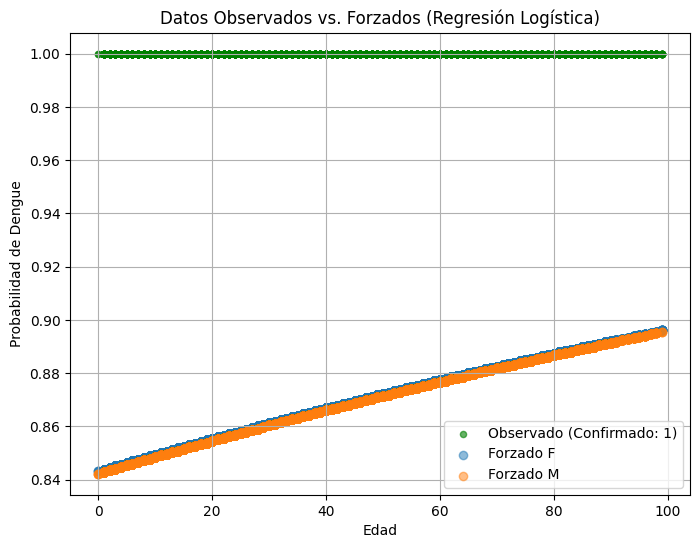

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener las predicciones del modelo para los datos de entrenamiento
df_f = df_interes[df_interes["sexo"] == "F"]
df_m = df_interes[df_interes["sexo"] == "M"]

y_pred_f = modelo.predict(df_f)
y_pred_m = modelo.predict(df_m)

# Crear un gráfico de dispersión con los datos observados y forzados
plt.figure(figsize=(8, 6))  # Ajustar el tamaño de la figura si es necesario
#plt.scatter(df_interes["Edad"], df_interes["Dx_Ferropenica"], label="Observado", alpha=0.5)  # Datos observados
plt.scatter(df_interes["edad"][df_interes["Dx_Confirmado"] == 1],
            df_interes["Dx_Confirmado"][df_interes["Dx_Confirmado"] == 1],
            color='green', label='Observado (Confirmado: 1)', alpha=0.6, s=20)

plt.scatter(df_f["edad"], y_pred_f, label="Forzado F", alpha=0.5)  # Datos forzados (predichos)
plt.scatter(df_m["edad"], y_pred_m, label="Forzado M", alpha=0.5)  # Datos forzados (predichos)

plt.xlabel("Edad")
plt.ylabel("Probabilidad de Dengue")
plt.title("Datos Observados vs. Forzados (Regresión Logística)")
plt.legend()
plt.grid(True)
plt.show()

# **IV. Referencias**

**Libros y manuales**

- [Libro de estadisitica con python ](https://www.editorial-sciela.org/index.php/sciela/article/view/16/49), [Introducción a la teoria de probabilidades](https://ciladi.org/wp-content/uploads/Version_final_Introduccion-Probabilidad-Python-vf_Bayas-3.pdf), [Guía practica de análsis exploratorio de python](https://datos.gob.es/sites/default/files/doc/file/guia_eda_python.pdf)

**Cursos en linea**

- [Estadística W3School](https://www.w3schools.com/statistics/index.php), [Estadística con python](https://docs.python.org/es/3/library/statistics.html), [Kaggle](https://www.kaggle.com/code/saurav9786/statistics-for-data-scientists)

**Aplicaciones IA**

- [Gemini iA](https://gemini.google.com), [DeepSeek](https://www.deepseek.com/), [ChatGPT](https://chatgpt.com/), [Claude IA](https://claude.ai/), [Julius IA:](https://julius.ai)